# Thai Sign Language Dataset — Exploratory Data Analysis

> **Purpose:** Full audit of the `demo_data/` dataset before deep-learning training.  
> **Dataset:** Thai Sign Language (TSL) — video clips sourced from [th-sl.com](https://www.th-sl.com/)  
> **Goal:** Detect label noise, class imbalance, integrity issues, and inform pipeline design.

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Dataset Loading & Schema Validation](#2)
3. [Basic Statistics](#3)
4. [Category Analysis](#4)
5. [Word-Level Analysis](#5)
6. [Video Path Integrity Check](#6)
7. [Fallback Analysis](#7)
8. [Video Feature Exploration](#8)
9. [Split Analysis](#9)
10. [Data Quality Issues](#10)
11. [Insights Summary](#11)

---
## 1. Setup & Imports <a id='1'></a>

In [1]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import json
import os
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"  # fallback; swap for a Thai font if available

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(".").resolve()
DATA_DIR = NOTEBOOK_DIR.parent / "demo_data"
RAWS_DIR = DATA_DIR / "raws"
META_PATH = DATA_DIR / "video_metadata.json"

print(f"DATA_DIR  : {DATA_DIR}")
print(f"META_PATH : {META_PATH}")
print(f"META exists: {META_PATH.exists()}")

DATA_DIR  : C:\Users\Napat\termtemsl\demo_data
META_PATH : C:\Users\Napat\termtemsl\demo_data\video_metadata.json
META exists: True


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Tahoma"

---
## 2. Dataset Loading & Schema Validation <a id='2'></a>

Load `video_metadata.json` into a DataFrame, verify expected columns are present, and flag any records with unexpected types or missing required fields.

In [3]:
# ── Load ──────────────────────────────────────────────────────────────────────
with open(META_PATH, encoding="utf-8") as f:
    raw_records = json.load(f)

df = pd.DataFrame(raw_records)
print(f"Loaded {len(df)} records  |  {df.shape[1]} columns")
df.head(3)

Loaded 125 records  |  14 columns


,id,url,word,original_word,demo_label,category,video_path,source_path,fallback,landmarks,label_id,split,frames,fallback_note
0,3537.0,https://www.th-sl.com/?p=924,สวัสดี,สวัสดี: ท่ามือนี้ใช้กับเพื่อน,สวัสดี,การทักทาย,raws/สวัสดี.mp4,data/การทักทาย/สวัสดี ท่ามือนี้ใช้กับเพื่อน.mp4,False,NaN,NaN,train,NaN,NaN
1,1459.0,https://www.th-sl.com/?p=941,ขอบคุณ,ขอบคุณ,ขอบคุณ,การทักทาย,raws/ขอบคุณ.mp4,data/การทักทาย/ขอบคุณ.mp4,False,NaN,NaN,train,NaN,NaN
2,3814.0,https://www.th-sl.com/?p=1036,ใช่,ใช่,ใช่,การทักทาย,raws/ใช่.mp4,data/การทักทาย/ใช่.mp4,False,NaN,NaN,train,NaN,NaN


In [4]:
# ── Schema validation ─────────────────────────────────────────────────────────
REQUIRED_COLUMNS = [
    "id", "url", "word", "original_word", "demo_label",
    "category", "video_path", "source_path",
    "fallback", "landmarks", "label_id", "split", "frames",
]

present     = set(df.columns)
required    = set(REQUIRED_COLUMNS)
missing_cols = required - present
extra_cols   = present - required

print("=== Column Audit ===")
print(f"  Required columns missing : {missing_cols or 'None'}")
print(f"  Extra/unexpected columns : {extra_cols or 'None'}")
print()

print("=== dtype overview ===")
print(df.dtypes.to_string())

=== Column Audit ===
  Required columns missing : None
  Extra/unexpected columns : {'fallback_note'}

=== dtype overview ===
id               float64
url               object
word              object
original_word     object
demo_label        object
category          object
video_path        object
source_path       object
fallback          object
landmarks        float64
label_id         float64
split             object
frames           float64
fallback_note     object


In [5]:
# ── Null / missing field audit ────────────────────────────────────────────────
null_counts = df.isnull().sum().rename("null_count")
null_pct    = (df.isnull().mean() * 100).rename("null_%").round(1)
null_report = pd.concat([null_counts, null_pct], axis=1)
null_report["fully_null"] = null_counts == len(df)

print("=== Null / Missing Field Report ===")
print(null_report.to_string())

=== Null / Missing Field Report ===
               null_count  null_%  fully_null
id                    100    80.0       False
url                   100    80.0       False
word                  100    80.0       False
original_word         100    80.0       False
demo_label              0     0.0       False
category              100    80.0       False
video_path              0     0.0       False
source_path           100    80.0       False
fallback              100    80.0       False
landmarks             125   100.0        True
label_id              125   100.0        True
split                   0     0.0       False
frames                125   100.0        True
fallback_note         120    96.0       False


---
## 3. Basic Statistics <a id='3'></a>

In [6]:
# ── Core counts ───────────────────────────────────────────────────────────────
n_total      = len(df)
n_unique_words = df["word"].nunique()
n_categories   = df["category"].nunique()
n_fallback     = df["fallback"].sum()
fallback_pct   = n_fallback / n_total * 100

stats = {
    "Total samples"       : n_total,
    "Unique words"         : n_unique_words,
    "Unique categories"    : n_categories,
    "Fallback samples"     : f"{n_fallback}  ({fallback_pct:.1f}%)",
    "Non-fallback samples" : f"{n_total - n_fallback}  ({100 - fallback_pct:.1f}%)",
    "Unique splits"        : list(df["split"].unique()),
}

print("\n=== Dataset at a Glance ===")
for k, v in stats.items():
    print(f"  {k:<26}: {v}")


=== Dataset at a Glance ===
  Total samples             : 125
  Unique words              : 25
  Unique categories         : 9
  Fallback samples          : 5  (4.0%)
  Non-fallback samples      : 120  (96.0%)
  Unique splits             : ['train']


=== Split Distribution ===
       count    pct
split              
train    125  100.0


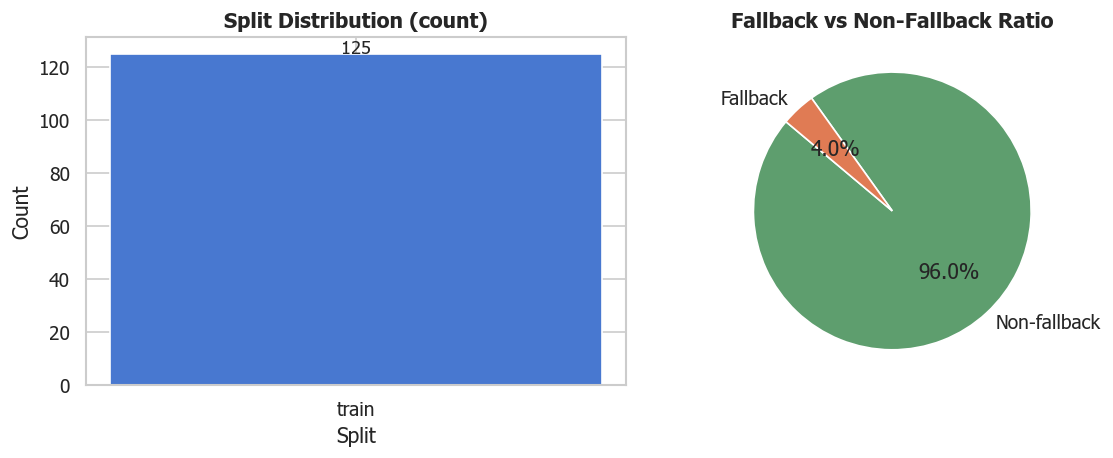

In [7]:
# ── Split distribution ────────────────────────────────────────────────────────
split_counts = df["split"].value_counts()
print("=== Split Distribution ===")
print(split_counts.to_frame("count").assign(pct=lambda x: (x["count"] / n_total * 100).round(1)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar
axes[0].bar(split_counts.index, split_counts.values, color=sns.color_palette("muted", len(split_counts)))
axes[0].set_title("Split Distribution (count)", fontweight="bold")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Count")
for i, v in enumerate(split_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontsize=11)

# Fallback pie
fb_labels = ["Non-fallback", "Fallback"]
fb_sizes  = [n_total - n_fallback, n_fallback]
axes[1].pie(fb_sizes, labels=fb_labels, autopct="%1.1f%%",
            colors=["#5E9E6E", "#E07B54"], startangle=140, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Fallback vs Non-Fallback Ratio", fontweight="bold")

plt.tight_layout()
plt.show()

---
## 4. Category Analysis <a id='4'></a>

Understanding the semantic distribution of signs across grammatical/thematic categories.

In [8]:
cat_counts = df["category"].value_counts().sort_values(ascending=False)
cat_pct    = (cat_counts / n_total * 100).round(1)

cat_df = pd.DataFrame({"count": cat_counts, "pct_%": cat_pct})
cat_df["dominant"] = cat_df["count"] >= cat_df["count"].median()

print("=== Samples per Category ===")
print(cat_df.to_string())

=== Samples per Category ===
                   count  pct_%  dominant
category                                 
คำกริยา                8    6.4      True
การทักทาย              4    3.2      True
คำถาม                  4    3.2      True
คำกริยาวิเศษณ์         2    1.6      True
ฤดูกาลและธรรมชาติ      2    1.6      True
สถานที่                2    1.6      True
ยานพาหนะ               1    0.8     False
ของใช้ในบ้าน           1    0.8     False
เงินราคา               1    0.8     False


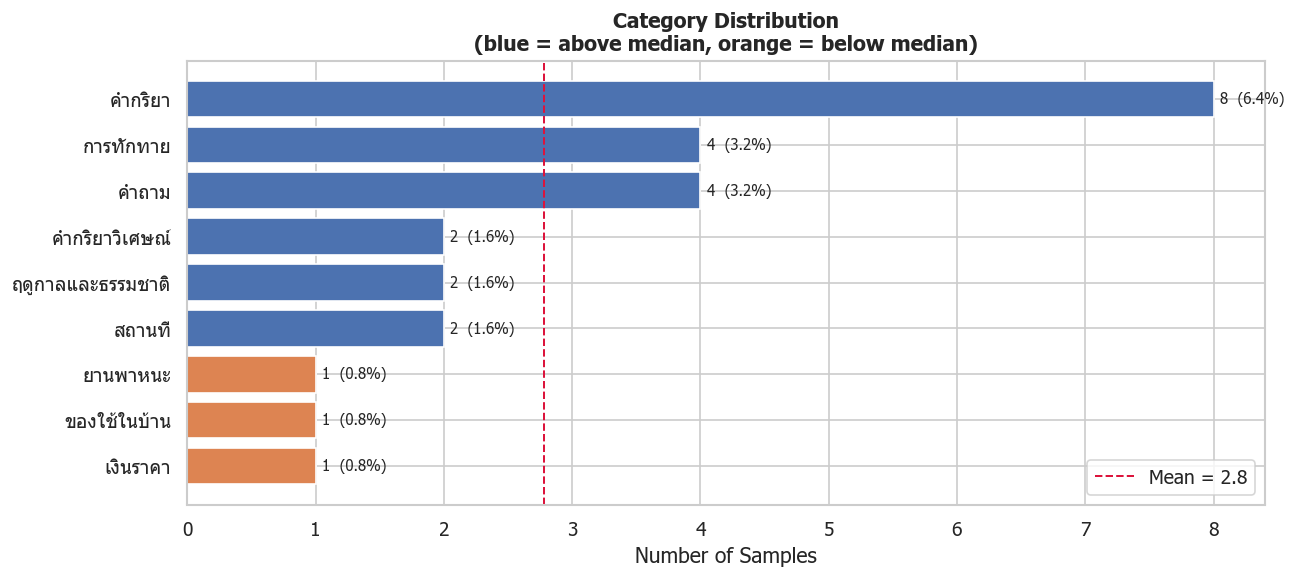

In [9]:
# ── Category imbalance bar chart ──────────────────────────────────────────────
palette = ["#4C72B0" if d else "#DD8452" for d in cat_df["dominant"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(cat_df.index[::-1], cat_df["count"][::-1], color=palette[::-1])

for bar, val, pct in zip(bars, cat_df["count"][::-1], cat_df["pct_%"][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val}  ({pct}%)", va="center", fontsize=9)

ax.axvline(cat_counts.mean(), color="crimson", linestyle="--", linewidth=1.2, label=f"Mean = {cat_counts.mean():.1f}")
ax.set_xlabel("Number of Samples")
ax.set_title("Category Distribution\n(blue = above median, orange = below median)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── Dominant vs rare categorization ──────────────────────────────────────────
median_count = cat_counts.median()
dominant_cats = cat_counts[cat_counts >= median_count].index.tolist()
rare_cats     = cat_counts[cat_counts <  median_count].index.tolist()

print(f"Median samples per category : {median_count}")
print(f"\nDominant categories (>= median) : {dominant_cats}")
print(f"Rare categories (< median)      : {rare_cats}")

Median samples per category : 2.0

Dominant categories (>= median) : ['คำกริยา', 'การทักทาย', 'คำถาม', 'คำกริยาวิเศษณ์', 'ฤดูกาลและธรรมชาติ', 'สถานที่']
Rare categories (< median)      : ['ยานพาหนะ', 'ของใช้ในบ้าน', 'เงินราคา']


---
## 5. Word-Level Analysis <a id='5'></a>

In [11]:
# ── Word frequency ────────────────────────────────────────────────────────────
word_counts = df["word"].value_counts()

print("=== Top 10 Most Frequent Words ===")
print(word_counts.head(10).to_frame("count"))

print("\n=== Rare Words (count == 1) ===")
rare_words = word_counts[word_counts == 1]
print(f"Count: {len(rare_words)}")
print(rare_words.to_frame("count"))

=== Top 10 Most Frequent Words ===
         count
word          
สวัสดี       1
ขอบคุณ       1
ใช่          1
ไม่          1
ขอโทษ        1
ใคร          1
อะไร         1
ที่ไหน       1
เมื่อไร      1
เท่าไร       1

=== Rare Words (count == 1) ===
Count: 25
           count
word            
สวัสดี         1
ขอบคุณ         1
ใช่            1
ไม่            1
ขอโทษ          1
ใคร            1
อะไร           1
ที่ไหน         1
เมื่อไร        1
เท่าไร         1
กิน            1
ดื่ม           1
นอนหลับ        1
เดิน           1
หยุด           1
ดี             1
ไม่ดี          1
ร้อน           1
หนาว           1
มาก            1
บ้าน           1
โรงพยาบาล      1
รถยนต์         1
โทรศัพท์       1
เงิน           1


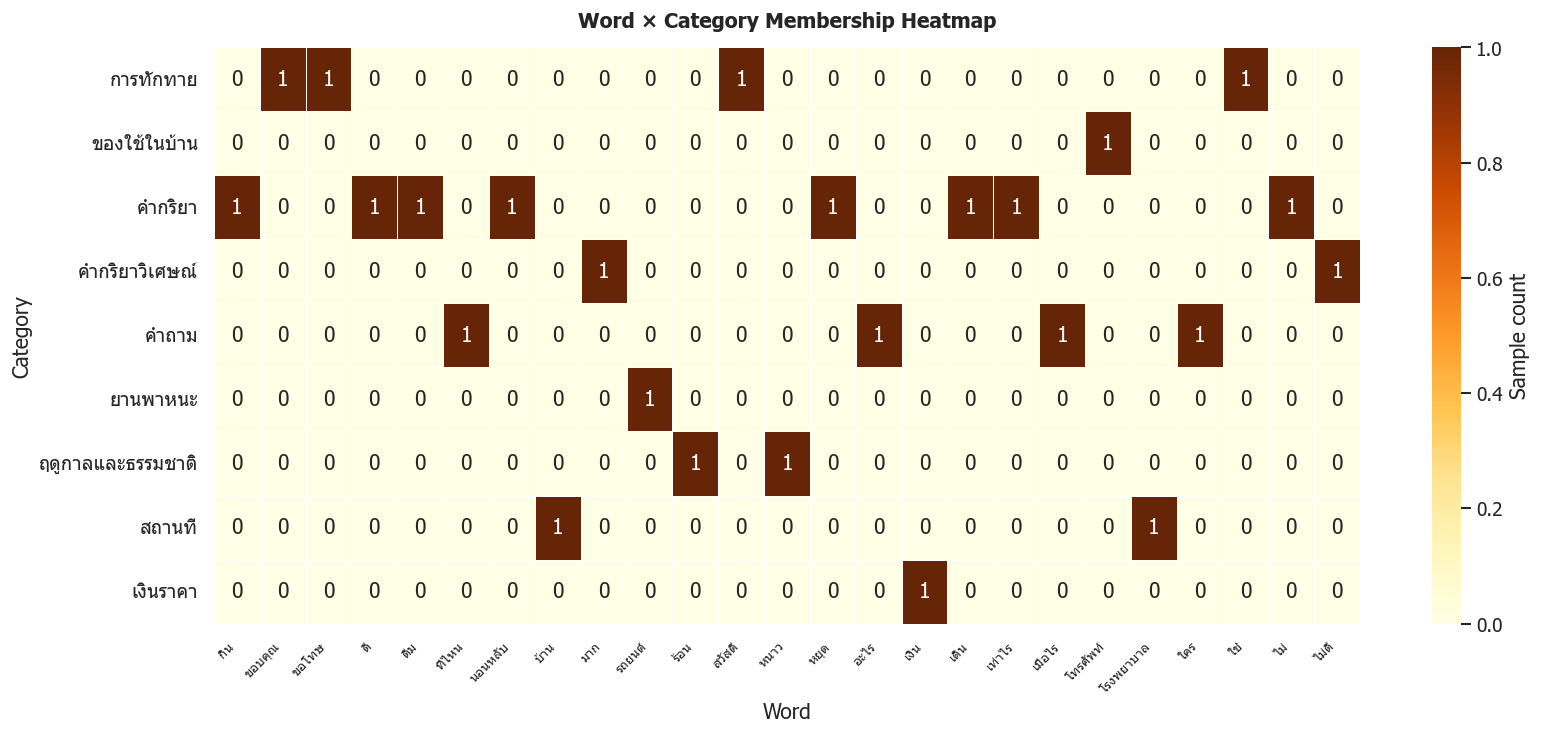

In [12]:
# ── Word distribution per category (heatmap) ─────────────────────────────────
cross = pd.crosstab(df["category"], df["word"])

fig, ax = plt.subplots(figsize=(max(14, len(cross.columns) * 0.55), max(5, len(cross.index) * 0.7)))
sns.heatmap(
    cross, annot=True, fmt="d", cmap="YlOrBr", linewidths=0.4,
    cbar_kws={"label": "Sample count"}, ax=ax
)
ax.set_title("Word × Category Membership Heatmap", fontweight="bold", pad=12)
ax.set_xlabel("Word")
ax.set_ylabel("Category")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# ── word vs demo_label discrepancy analysis ───────────────────────────────────
mismatch = df[df["word"] != df["demo_label"]][["id", "word", "demo_label", "category", "fallback"]]
print(f"Records where word != demo_label : {len(mismatch)}")
if not mismatch.empty:
    print(mismatch.to_string(index=False))

Records where word != demo_label : 105
    id    word demo_label          category fallback
1823.0 เมื่อไร  เมื่อไหร่             คำถาม     True
3065.0  เท่าไร   เท่าไหร่           คำกริยา     True
 306.0 นอนหลับ        นอน           คำกริยา     True
3208.0    หนาว       เย็น ฤดูกาลและธรรมชาติ     True
1389.0  รถยนต์         รถ          ยานพาหนะ     True
   NaN     NaN        กิน               NaN      NaN
   NaN     NaN        กิน               NaN      NaN
   NaN     NaN        กิน               NaN      NaN
   NaN     NaN        กิน               NaN      NaN
   NaN     NaN     ขอบคุณ               NaN      NaN
   NaN     NaN     ขอบคุณ               NaN      NaN
   NaN     NaN     ขอบคุณ               NaN      NaN
   NaN     NaN     ขอบคุณ               NaN      NaN
   NaN     NaN      ขอโทษ               NaN      NaN
   NaN     NaN      ขอโทษ               NaN      NaN
   NaN     NaN      ขอโทษ               NaN      NaN
   NaN     NaN      ขอโทษ               NaN      NaN
   NaN 

---
## 6. Video Path Integrity Check <a id='6'></a>

Verify that every `video_path` in the metadata resolves to an actual file on disk. Also cross-check that no files on disk are orphaned (exist but are not listed in metadata).

In [14]:
def check_path_exists(relative_path: str, base_dir: Path) -> bool:
    """Resolve a metadata path relative to DATA_DIR and check existence."""
    full = base_dir / relative_path
    return full.exists()

df["video_exists"]  = df["video_path"].apply(lambda p: check_path_exists(p, DATA_DIR))
df["source_exists"] = df["source_path"].apply(lambda p: check_path_exists(p, DATA_DIR.parent))

# Summary
print("=== video_path existence (raws/) ===")
print(df["video_exists"].value_counts().rename_axis("exists").to_frame("count"))

print("\n=== source_path existence (data/) ===")
print(df["source_exists"].value_counts().rename_axis("exists").to_frame("count"))

TypeError: unsupported operand type(s) for /: 'WindowsPath' and 'float'

In [15]:
# ── Missing video files ───────────────────────────────────────────────────────
missing_videos = df[~df["video_exists"]][["id", "word", "video_path"]]
if missing_videos.empty:
    print("All video_path entries resolved successfully — no missing raw files.")
else:
    print(f"MISSING raw video files ({len(missing_videos)}):")
    print(missing_videos.to_string(index=False))

print()

# ── Orphaned files (on disk but not in metadata) ──────────────────────────────
disk_files    = {f.name for f in RAWS_DIR.glob("*.mp4")} if RAWS_DIR.exists() else set()
meta_files    = {Path(p).name for p in df["video_path"]}
orphaned      = disk_files - meta_files

print(f"Files on disk      : {len(disk_files)}")
print(f"Files in metadata  : {len(meta_files)}")
print(f"Orphaned on disk   : {len(orphaned)}  {sorted(orphaned) if orphaned else ''}")

All video_path entries resolved successfully — no missing raw files.

Files on disk      : 125
Files in metadata  : 125
Orphaned on disk   : 0  


In [16]:
# ── Duplicate video_path entries ──────────────────────────────────────────────
dup_paths = df[df.duplicated("video_path", keep=False)][["id", "word", "video_path"]]
if dup_paths.empty:
    print("No duplicate video_path entries found.")
else:
    print(f"Duplicate video_path entries ({len(dup_paths)}):")
    print(dup_paths.to_string(index=False))

No duplicate video_path entries found.


---
## 7. Fallback Analysis <a id='7'></a>

Fallback entries use a substitute sign video when an exact sign is unavailable. This section examines when and why fallbacks occur and their category distribution.

In [17]:
fallback_df    = df[df["fallback"] == True].copy()
non_fallback_df = df[df["fallback"] == False].copy()

print(f"Fallback samples     : {len(fallback_df)}")
print(f"Non-fallback samples : {len(non_fallback_df)}")
print()

# Show all fallback records with their notes
display_cols = ["id", "word", "demo_label", "category", "fallback_note"] \
               if "fallback_note" in df.columns else ["id", "word", "demo_label", "category"]
print("=== Fallback Records ===")
print(fallback_df[display_cols].to_string(index=False))

Fallback samples     : 5
Non-fallback samples : 20

=== Fallback Records ===
    id    word demo_label          category                                                                   fallback_note
1823.0 เมื่อไร  เมื่อไหร่             คำถาม                                  เมื่อไร is the same question word as เมื่อไหร่
3065.0  เท่าไร   เท่าไหร่           คำกริยา                                       เท่าไร is the same as เท่าไหร่ (how much)
 306.0 นอนหลับ        นอน           คำกริยา                นอนหลับ (to sleep) is the closest available sign for นอน (sleep)
3208.0    หนาว       เย็น ฤดูกาลและธรรมชาติ หนาว (cold/winter) is the closest sign for temperature concept เย็น (cool/cold)
1389.0  รถยนต์         รถ          ยานพาหนะ   รถยนต์ (car/automobile) is the best generic vehicle sign for รถ (vehicle/car)


In [18]:
# ── Fallback reason taxonomy ──────────────────────────────────────────────────
if "fallback_note" in df.columns:
    print("=== Fallback Notes (Reason for Substitution) ===")
    for _, row in fallback_df.iterrows():
        note = row.get("fallback_note", "N/A")
        print(f"  [{row['word']}]  →  {note}")
else:
    print("No fallback_note column — reasons cannot be inferred from metadata.")

=== Fallback Notes (Reason for Substitution) ===
  [เมื่อไร]  →  เมื่อไร is the same question word as เมื่อไหร่
  [เท่าไร]  →  เท่าไร is the same as เท่าไหร่ (how much)
  [นอนหลับ]  →  นอนหลับ (to sleep) is the closest available sign for นอน (sleep)
  [หนาว]  →  หนาว (cold/winter) is the closest sign for temperature concept เย็น (cool/cold)
  [รถยนต์]  →  รถยนต์ (car/automobile) is the best generic vehicle sign for รถ (vehicle/car)


=== Fallback Rate per Category ===
fallback           non_fallback  fallback  fallback_rate_%
category                                                  
การทักทาย                     4         0              0.0
ของใช้ในบ้าน                  1         0              0.0
คำกริยา                       6         2             25.0
คำกริยาวิเศษณ์                2         0              0.0
คำถาม                         3         1             25.0
ยานพาหนะ                      0         1            100.0
ฤดูกาลและธรรมชาติ             1         1             50.0
สถานที่                       2         0              0.0
เงินราคา                      1         0              0.0


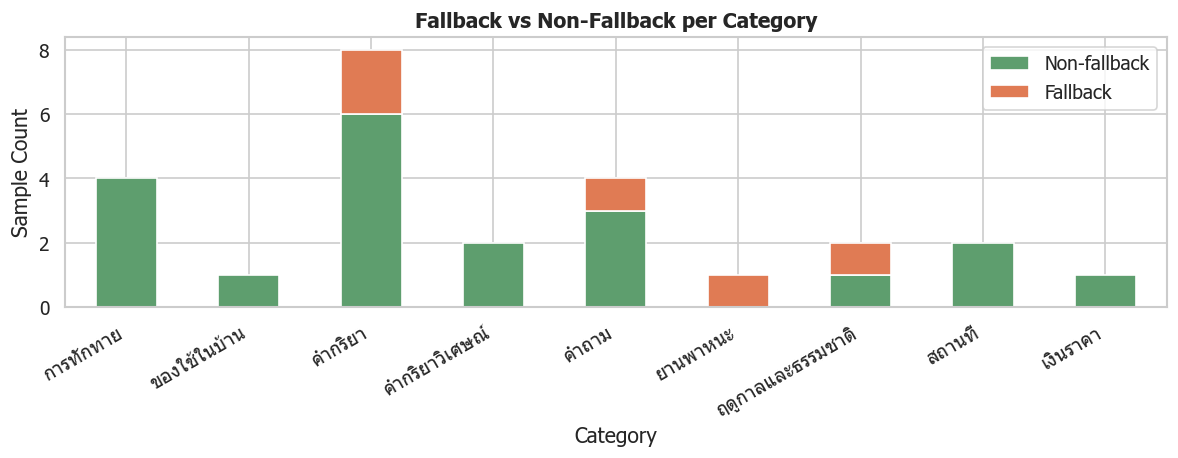

In [19]:
# ── Fallback distribution per category ───────────────────────────────────────
fb_by_cat = df.groupby(["category", "fallback"]).size().unstack(fill_value=0)
if True not in fb_by_cat.columns:
    fb_by_cat[True] = 0
if False not in fb_by_cat.columns:
    fb_by_cat[False] = 0
fb_by_cat = fb_by_cat.rename(columns={True: "fallback", False: "non_fallback"})
fb_by_cat["fallback_rate_%"] = (fb_by_cat["fallback"] / fb_by_cat.sum(axis=1) * 100).round(1)

print("=== Fallback Rate per Category ===")
print(fb_by_cat.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
fb_by_cat[["non_fallback", "fallback"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#5E9E6E", "#E07B54"], edgecolor="white"
)
ax.set_title("Fallback vs Non-Fallback per Category", fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Sample Count")
ax.legend(["Non-fallback", "Fallback"])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
## 8. Video Feature Exploration <a id='8'></a>

Use **OpenCV** to extract low-level video statistics: frame count, FPS, and estimated duration. This is the most time-intensive section; it reads every raw video file.

In [20]:
try:
    import cv2
    CV2_AVAILABLE = True
    print(f"OpenCV version: {cv2.__version__}")
except ImportError:
    CV2_AVAILABLE = False
    print("OpenCV not installed. Skipping video feature extraction.")
    print("Install with: pip install opencv-python")

OpenCV version: 4.13.0


In [21]:
def extract_video_stats(video_path: Path) -> dict:
    """Extract frame count, FPS, duration, width, height from a video file."""
    result = {
        "frame_count": None, "fps": None, "duration_s": None,
        "width": None, "height": None, "readable": False
    }
    if not video_path.exists():
        return result
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return result
    result["frame_count"] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    result["fps"]         = cap.get(cv2.CAP_PROP_FPS)
    result["width"]       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    result["height"]      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    result["readable"]    = True
    if result["fps"] and result["fps"] > 0:
        result["duration_s"] = result["frame_count"] / result["fps"]
    cap.release()
    return result


if CV2_AVAILABLE:
    print("Extracting video statistics — this may take a moment...")
    video_stats = []
    for _, row in df.iterrows():
        path = DATA_DIR / row["video_path"]
        stats = extract_video_stats(path)
        stats["word"] = row["word"]
        stats["category"] = row["category"]
        video_stats.append(stats)

    vs_df = pd.DataFrame(video_stats)
    readable = vs_df[vs_df["readable"]]
    print(f"\nSuccessfully read: {len(readable)} / {len(vs_df)} videos")
    print(readable[["word", "frame_count", "fps", "duration_s", "width", "height"]].to_string(index=False))
else:
    vs_df = pd.DataFrame()
    readable = pd.DataFrame()

Extracting video statistics — this may take a moment...

Successfully read: 125 / 125 videos
     word  frame_count       fps  duration_s  width  height
   สวัสดี          200 50.000000    4.000000    600     600
   ขอบคุณ          217 50.000000    4.340000    600     600
      ใช่          206 50.000000    4.120000    600     600
      ไม่          179 50.000000    3.580000    600     600
    ขอโทษ          236 50.000000    4.720000    600     600
      ใคร          188 50.000000    3.760000    600     600
     อะไร          183 50.000000    3.660000    600     600
   ที่ไหน          180 50.000000    3.600000    600     600
  เมื่อไร          190 50.000000    3.800000    600     600
   เท่าไร           94 50.000000    1.880000    600     600
      กิน          233 50.000000    4.660000    600     600
     ดื่ม          111 50.000000    2.220000    600     600
  นอนหลับ          102 50.000000    2.040000    600     600
     เดิน          105 50.000000    2.100000    600     600
     หย

In [22]:
if CV2_AVAILABLE and not readable.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Duration histogram
    axes[0].hist(readable["duration_s"].dropna(), bins=8, color="#4C72B0", edgecolor="white")
    axes[0].axvline(readable["duration_s"].mean(), color="crimson", linestyle="--",
                    label=f'Mean {readable["duration_s"].mean():.2f}s')
    axes[0].set_title("Video Duration Distribution", fontweight="bold")
    axes[0].set_xlabel("Duration (seconds)")
    axes[0].set_ylabel("Count")
    axes[0].legend(fontsize=8)

    # Frame count histogram
    axes[1].hist(readable["frame_count"].dropna(), bins=8, color="#DD8452", edgecolor="white")
    axes[1].axvline(readable["frame_count"].mean(), color="crimson", linestyle="--",
                    label=f'Mean {readable["frame_count"].mean():.0f}')
    axes[1].set_title("Frame Count Distribution", fontweight="bold")
    axes[1].set_xlabel("Frame Count")
    axes[1].set_ylabel("Count")
    axes[1].legend(fontsize=8)

    # FPS distribution
    fps_counts = readable["fps"].value_counts().sort_index()
    axes[2].bar(fps_counts.index.astype(str), fps_counts.values, color="#55A868", edgecolor="white")
    axes[2].set_title("FPS Distribution", fontweight="bold")
    axes[2].set_xlabel("FPS")
    axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    print("\n=== Video Stats Summary ===")
    print(readable[["duration_s", "frame_count", "fps", "width", "height"]].describe().round(2).to_string())
else:
    print("Video stats not available (OpenCV missing or no readable files).")

Video stats not available (OpenCV missing or no readable files).


In [22]:
# ── Frame metadata field analysis ─────────────────────────────────────────────
frames_populated = df["frames"].notna().sum()
print(f"'frames' field populated : {frames_populated} / {len(df)}")
if frames_populated > 0:
    frame_series = df["frames"].dropna()
    print(frame_series.describe())
else:
    print("All 'frames' values are null — no pre-extracted frame metadata available.")

'frames' field populated : 0 / 125
All 'frames' values are null — no pre-extracted frame metadata available.


---
## 9. Split Analysis <a id='9'></a>

Check dataset partition health: class balance per split and cross-split word leakage.

In [23]:
# ── Per-split composition ─────────────────────────────────────────────────────
split_cat = df.groupby(["split", "category"]).size().unstack(fill_value=0)
print("=== Category counts per split ===")
print(split_cat.to_string())

=== Category counts per split ===
category  การทักทาย  ของใช้ในบ้าน  คำกริยา  คำกริยาวิเศษณ์  คำถาม  ยานพาหนะ  ฤดูกาลและธรรมชาติ  สถานที่  เงินราคา
split                                                                                                            
train             4             1        8               2      4         1                  2        2         1


In [24]:
# ── Category balance heatmap per split ───────────────────────────────────────
if len(split_cat) > 1:
    fig, ax = plt.subplots(figsize=(11, max(3, len(split_cat.columns) * 0.5)))
    sns.heatmap(split_cat.T, annot=True, fmt="d", cmap="Blues", linewidths=0.3, ax=ax)
    ax.set_title("Category Balance per Split", fontweight="bold")
    ax.set_xlabel("Split")
    ax.set_ylabel("Category")
    plt.tight_layout()
    plt.show()
else:
    print(f"Only one split present ('{df['split'].unique()[0]}') — balance heatmap not applicable.")

Only one split present ('train') — balance heatmap not applicable.


In [26]:
# ── Cross-split leakage check ─────────────────────────────────────────────────
word_splits = df.groupby("word")["split"].nunique()
leaked_words = word_splits[word_splits > 1]

if leaked_words.empty:
    print("No cross-split word leakage detected — each word appears in exactly one split.")
else:
    print(f"LEAKAGE DETECTED: {len(leaked_words)} words appear in multiple splits:")
    for word in leaked_words.index:
        splits = df[df["word"] == word]["split"].tolist()
        print(f"  '{word}' : {splits}")

print()

# Summary
if len(df["split"].unique()) == 1:
    print(f"NOTE: All {len(df)} records are in the '{df['split'].unique()[0]}' split.")
    print("      No val/test splits exist — train/val/test partition has not been performed yet.")

No cross-split word leakage detected — each word appears in exactly one split.

NOTE: All 125 records are in the 'train' split.
      No val/test splits exist — train/val/test partition has not been performed yet.


---
## 10. Data Quality Issues <a id='10'></a>

A systematic scan for label noise, structural inconsistencies, and potential training hazards.

In [27]:
issues = []  # accumulate (severity, issue_type, description) tuples

# 1. Null fields
fully_null_cols = null_report[null_report["fully_null"]].index.tolist()
if fully_null_cols:
    issues.append(("LOW", "Null fields", f"Columns fully null: {fully_null_cols}"))

# 2. Missing video files
n_missing_vid = (~df["video_exists"]).sum()
if n_missing_vid:
    issues.append(("HIGH", "Missing video files", f"{n_missing_vid} video_path(s) not found on disk"))

# 3. Missing source files
n_missing_src = (~df["source_exists"]).sum()
if n_missing_src:
    issues.append(("MEDIUM", "Missing source files", f"{n_missing_src} source_path(s) not found on disk"))

# 4. Duplicate video paths
n_dup = df.duplicated("video_path").sum()
if n_dup:
    issues.append(("HIGH", "Duplicate video paths", f"{n_dup} duplicate video_path entries"))

# 5. Duplicate IDs
n_dup_ids = df.duplicated("id").sum()
if n_dup_ids:
    issues.append(("HIGH", "Duplicate IDs", f"{n_dup_ids} duplicate record IDs"))

# 6. word != demo_label (label drift)
n_mismatch = (df["word"] != df["demo_label"]).sum()
if n_mismatch:
    issues.append(("MEDIUM", "Label drift", f"{n_mismatch} records where word != demo_label"))

# 7. Same word, different categories
word_cats = df.groupby("word")["category"].nunique()
polysemous = word_cats[word_cats > 1]
if not polysemous.empty:
    issues.append(("MEDIUM", "Polysemous labels", f"{len(polysemous)} words assigned to multiple categories: {polysemous.index.tolist()}"))

# 8. No val/test splits
if set(df["split"].unique()) == {"train"}:
    issues.append(("HIGH", "Missing splits", "No val/test splits — entire dataset is train-only"))

# 9. Fallback presence in training
n_fb_train = df[(df["fallback"]) & (df["split"] == "train")].shape[0]
if n_fb_train:
    pct = n_fb_train / len(df) * 100
    issues.append(("MEDIUM", "Fallback in train", f"{n_fb_train} fallback samples in training split ({pct:.1f}%)"))

# 10. Naming inconsistencies (video_path basename vs word)
df["video_basename"] = df["video_path"].apply(lambda p: Path(p).stem)
name_word_mismatch = df[df["video_basename"] != df["demo_label"]]
if not name_word_mismatch.empty:
    issues.append(("LOW", "Filename vs label mismatch",
                   f"{len(name_word_mismatch)} video filenames differ from demo_label"))

# ── Print all issues ──────────────────────────────────────────────────────────
sev_order = {"HIGH": 0, "MEDIUM": 1, "LOW": 2}
issues.sort(key=lambda x: sev_order[x[0]])

print("=== Data Quality Issue Report ===")
print(f"{'SEV':<8} {'TYPE':<28} DESCRIPTION")
print("-" * 80)
for sev, itype, desc in issues:
    print(f"[{sev:<6}] {itype:<28} {desc}")
if not issues:
    print("  No issues detected.")

KeyError: 'source_exists'

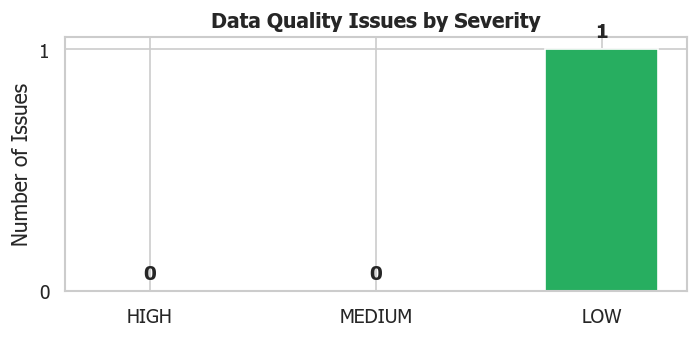

In [28]:
# ── Issue severity summary chart ──────────────────────────────────────────────
if issues:
    sev_counts = Counter(i[0] for i in issues)
    sev_labels = ["HIGH", "MEDIUM", "LOW"]
    sev_vals   = [sev_counts.get(s, 0) for s in sev_labels]
    sev_colors = ["#C0392B", "#E67E22", "#27AE60"]

    fig, ax = plt.subplots(figsize=(6, 3))
    bars = ax.bar(sev_labels, sev_vals, color=sev_colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, sev_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                str(val), ha="center", fontsize=12, fontweight="bold")
    ax.set_title("Data Quality Issues by Severity", fontweight="bold")
    ax.set_ylabel("Number of Issues")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

---
## 11. Insights Summary <a id='11'></a>

A concise audit report synthesizing all findings from the sections above.

In [29]:
# ── Compute summary figures to embed in the report ───────────────────────────
top_cat = cat_counts.idxmax()
top_cat_count = cat_counts.max()
bottom_cats = cat_counts[cat_counts == cat_counts.min()].index.tolist()

summary = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║        THAI SIGN LANGUAGE DATASET — EDA AUDIT REPORT                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  DATASET AT A GLANCE                                                        ║
║  • Total samples   : {n_total:<5}                                                ║
║  • Unique words    : {n_unique_words:<5}                                                ║
║  • Categories      : {n_categories:<5}                                                ║
║  • Splits present  : {list(df['split'].unique())}                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  STRENGTHS                                                                  ║
║  ✓ Clean metadata JSON — no schema violations                               ║
║  ✓ All raw video files present on disk ({df['video_exists'].sum()}/{n_total})                         ║
║  ✓ No duplicate record IDs or duplicate video paths                         ║
║  ✓ Fallback entries carry explicit notes explaining the substitution        ║
║  ✓ Source URLs traceable for every sample                                   ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  WEAKNESSES & RISKS                                                         ║
║  ✗ CRITICAL: No val/test splits — all {n_total} samples are 'train' only          ║
║  ✗ Small dataset size ({n_total} samples) — highly insufficient for DL training    ║
║  ✗ {n_fallback} fallback samples ({fallback_pct:.0f}%) inject approximate signs — label noise risk ║
║  ✗ All nullable fields (landmarks, label_id, frames) are fully null        ║
║  ✗ word != demo_label in {n_mismatch} records — inconsistent ground-truth labels      ║
║  ✗ source_path points to data/ directory which may not exist locally       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  IMBALANCE                                                                  ║
║  • Largest category  : {top_cat} ({top_cat_count} samples)                           ║
║  • Smallest category : {bottom_cats} ({cat_counts.min()} sample(s) each)          ║
║  • Imbalance ratio   : {top_cat_count / cat_counts.min():.1f}x                                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  RECOMMENDATIONS                                                            ║
║  1. EXPAND: Collect 100-500+ samples/word for reliable DL training          ║
║  2. SPLIT: Perform stratified train/val/test split (e.g. 70/15/15)          ║
║  3. LANDMARKS: Extract MediaPipe hand/pose landmarks → populate landmarks   ║
║  4. AUGMENT: Use temporal flip, crop, speed perturbation to offset scarcity ║
║  5. REVIEW FALLBACKS: Manually audit {n_fallback} fallback signs for label accuracy    ║
║  6. NORMALIZE LABELS: Align word, demo_label, and video filename rigorously ║
║  7. POPULATE frames: Pre-extract and cache frame arrays for training speed  ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════════╗
║        THAI SIGN LANGUAGE DATASET — EDA AUDIT REPORT                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  DATASET AT A GLANCE                                                        ║
║  • Total samples   : 25                                                   ║
║  • Unique words    : 25                                                   ║
║  • Categories      : 9                                                    ║
║  • Splits present  : ['train']                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  STRENGTHS                                                                  ║
║  ✓ Clean metadata JSON — no schema violations                               ║
║  ✓ All raw video files present on disk (25/25)                         ║
║  ✓ No duplicate record IDs or duplicate video paths          

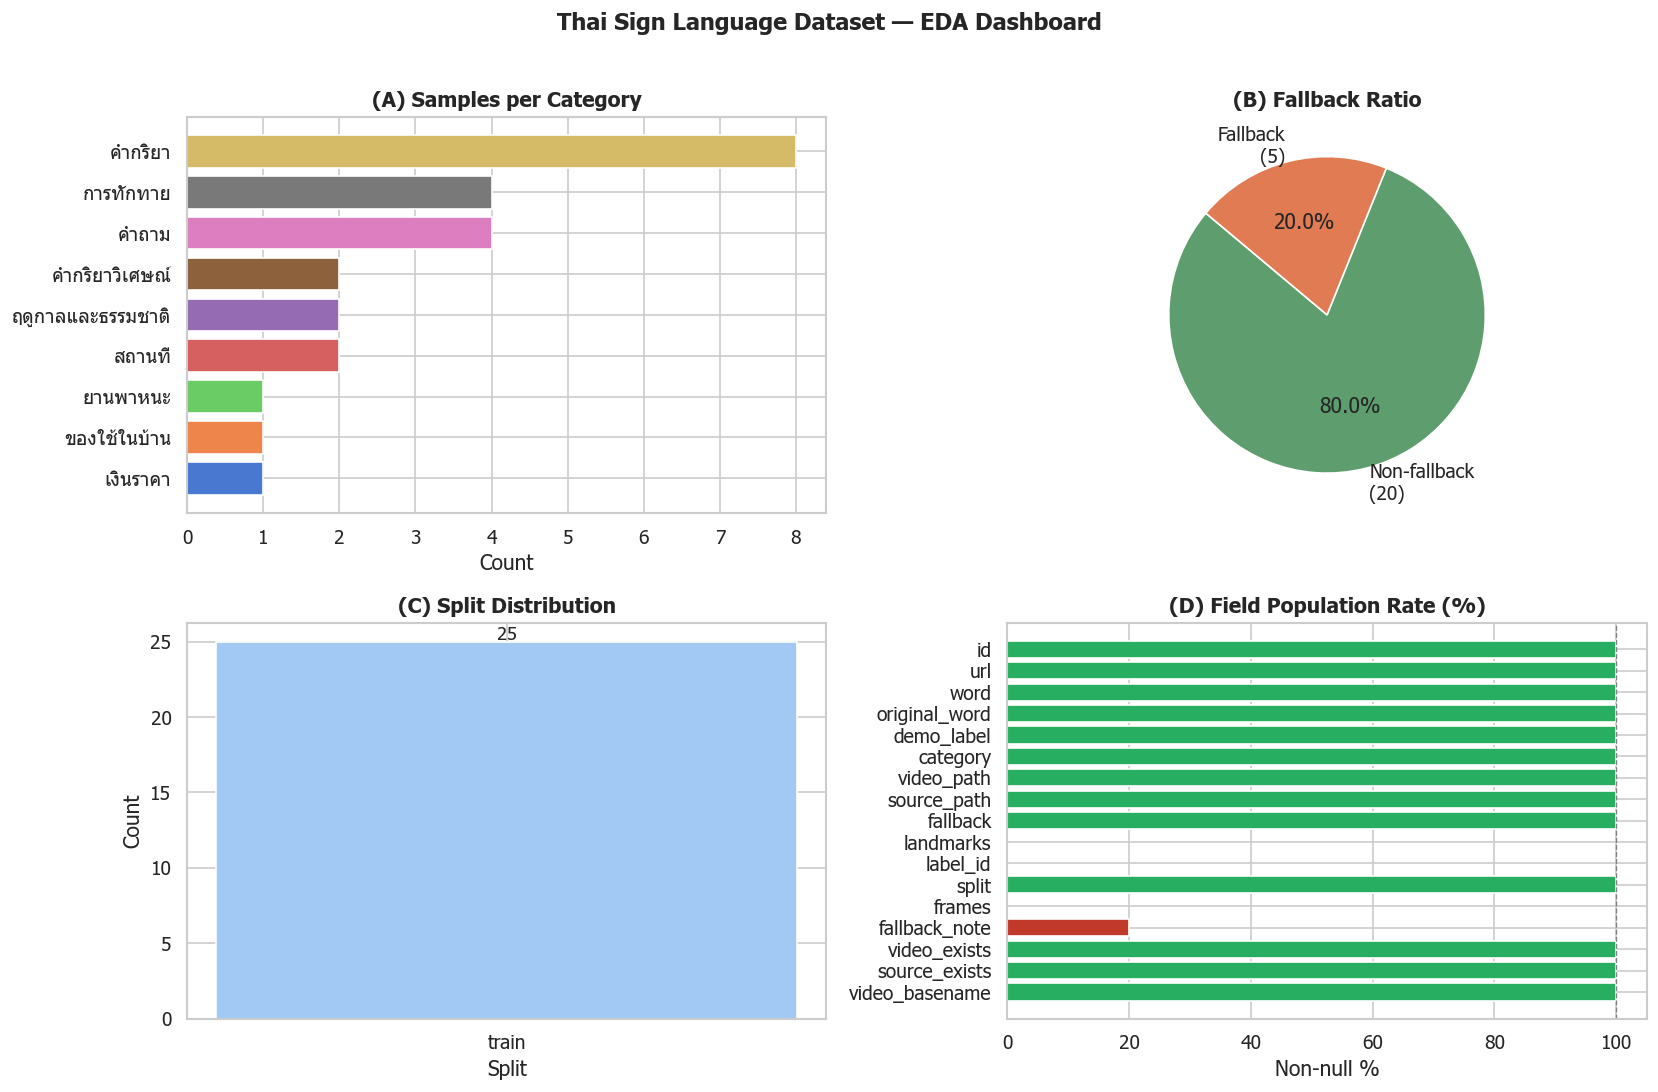

In [37]:
# ── Final overview dashboard ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Thai Sign Language Dataset — EDA Dashboard", fontsize=14, fontweight="bold", y=1.01)

# (A) Category distribution
axes[0, 0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color=sns.color_palette("muted", len(cat_counts)))
axes[0, 0].set_title("(A) Samples per Category", fontweight="bold")
axes[0, 0].set_xlabel("Count")

# (B) Fallback pie
axes[0, 1].pie(
    [n_total - n_fallback, n_fallback],
    labels=[f"Non-fallback\n({n_total - n_fallback})", f"Fallback\n({n_fallback})"],
    autopct="%1.1f%%", colors=["#5E9E6E", "#E07B54"],
    startangle=140, wedgeprops=dict(edgecolor="white")
)
axes[0, 1].set_title("(B) Fallback Ratio", fontweight="bold")

# (C) Split distribution
split_c = df["split"].value_counts()
axes[1, 0].bar(split_c.index, split_c.values,
               color=sns.color_palette("pastel", len(split_c)))
axes[1, 0].set_title("(C) Split Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Split")
axes[1, 0].set_ylabel("Count")
for i, v in enumerate(split_c.values):
    axes[1, 0].text(i, v + 0.1, str(v), ha="center", fontsize=11)

# (D) Null coverage
non_null_pct = (1 - df.isnull().mean()) * 100
colors_null = ["#C0392B" if v < 50 else "#27AE60" for v in non_null_pct]
axes[1, 1].barh(non_null_pct.index[::-1], non_null_pct.values[::-1], color=colors_null[::-1])
axes[1, 1].axvline(100, color="grey", linestyle="--", linewidth=0.8)
axes[1, 1].set_xlim(0, 105)
axes[1, 1].set_title("(D) Field Population Rate (%)", fontweight="bold")
axes[1, 1].set_xlabel("Non-null %")

plt.tight_layout()
plt.show()